In [5]:
!pip install -q wordcloud nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jeevitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [163]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv') # change filename
print(df.head())
print(df.shape)
print(df.columns)
print(f'\n📊 Total tickets: {len(df):,}')

                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous
(47837, 2)
Index(['Document', 'Topic_group'], dtype='object')

📊 Total tickets: 47,837


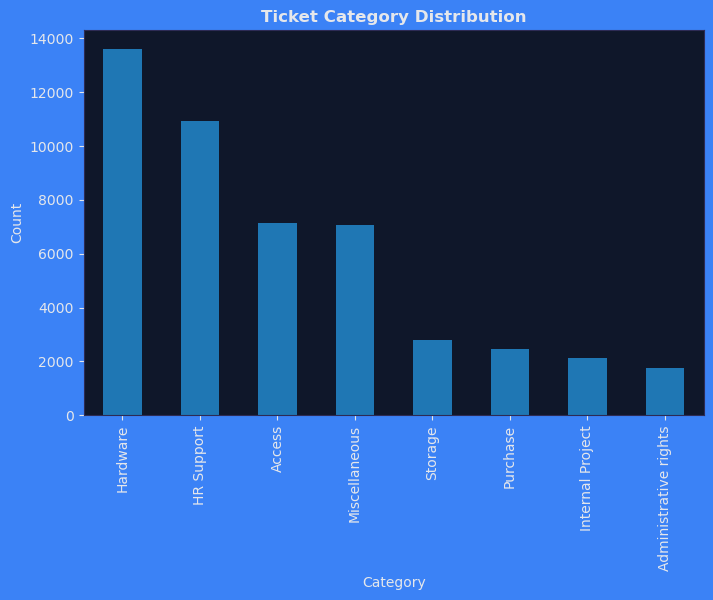

<Figure size 640x480 with 0 Axes>

In [191]:
plt.figure(figsize=(8,5))
df['Topic_group'].value_counts().plot(kind='bar')
plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()
plt.savefig('Ticket Category Distribution.png')

In [19]:
print('━'*60)
print('  DATASET — IT Service Tickets')
print('━'*60)

print(f'Columns  : {df.columns.tolist()}')
print(f'Nulls    : {df.isnull().sum().to_dict()}')
print(f'Categories ({df["Topic_group"].nunique()}):')
print(df['Topic_group'].value_counts().to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET — IT Service Tickets
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Columns  : ['Document', 'Topic_group']
Nulls    : {'Document': 0, 'Topic_group': 0}
Categories (8):
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760


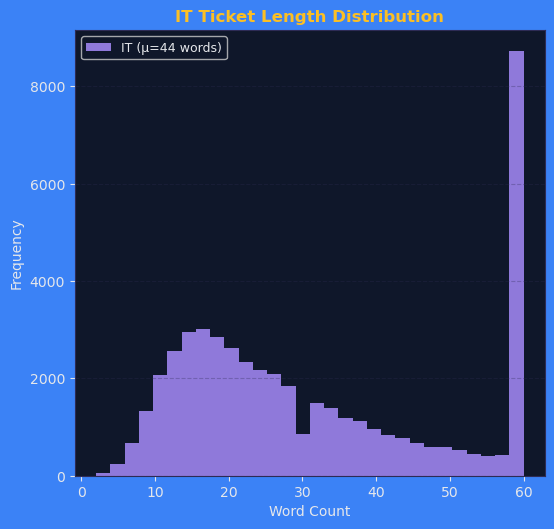

<Figure size 640x480 with 0 Axes>

In [189]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure + GridSpec
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3)

# Token length distribution (IT ONLY)
ax4 = fig.add_subplot(gs[1, 2])

it_len = df['Document'].str.split().str.len()

ax4.hist(it_len.clip(0, 60),
         bins=30,
         alpha=0.85,
         color=A1,
         edgecolor='none',
         label=f'IT (μ={it_len.mean():.0f} words)')

ax4.set_title('IT Ticket Length Distribution', color=A4)
ax4.set_xlabel('Word Count')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('IT Ticket length distribution.png')

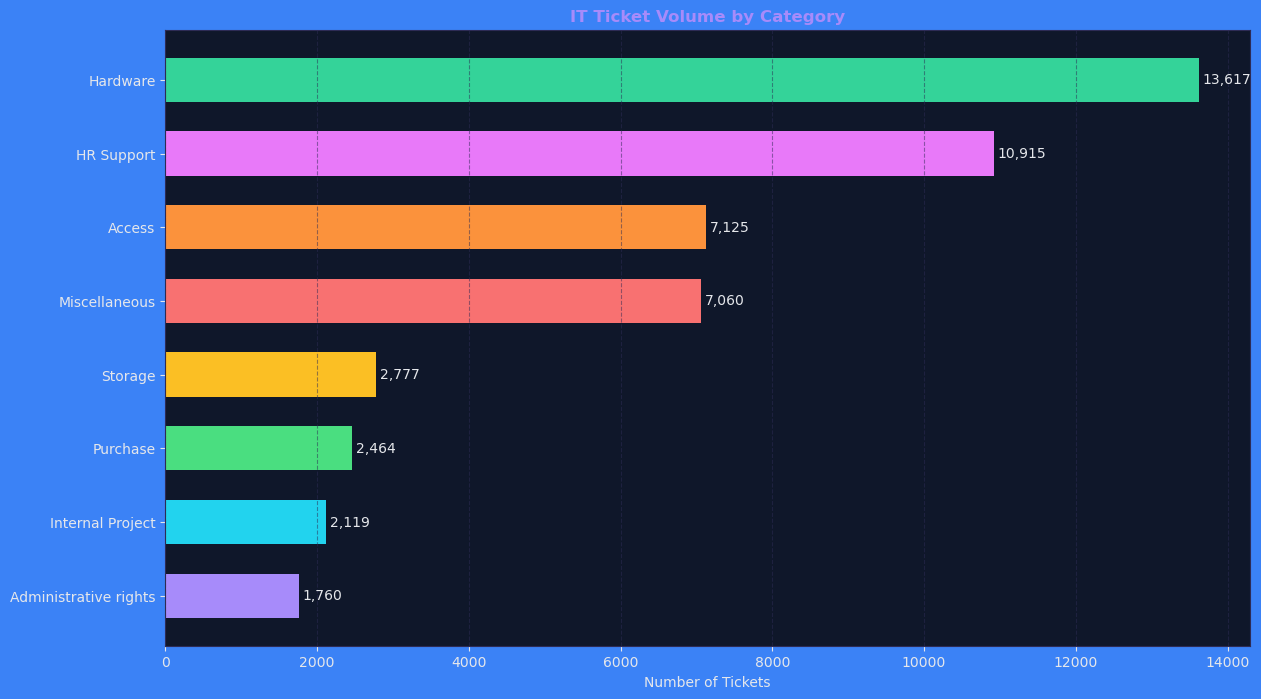

In [187]:
BG      = '#3b82f6'
CARD    = '#0f172a'
plt.rcParams.update({
    'figure.facecolor': BG,    'axes.facecolor':  CARD,
    'axes.edgecolor':   '#2d2b55', 'axes.labelcolor': TXT,
    'xtick.color': TXT,        'ytick.color': TXT,
    'text.color':  TXT,        'grid.color': '#2d2b55',
    'grid.linestyle': '--',    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,      'axes.titleweight': 'bold',
    'axes.titlecolor': TXT,
})
A1, A2, A3, A4, A5 = '#a78bfa', '#22d3ee', '#4ade80', '#fbbf24', '#f87171'
TXT     = '#e2e8f0'
PALETTE = [A1, A2, A3, A4, A5, '#fb923c', '#e879f9', '#34d399',
           '#60a5fa', '#f472b6', '#a3e635', '#38bdf8', '#c084fc']
fig = plt.figure(figsize=(14, 8), facecolor=BG)

ax1 = fig.add_subplot(111)
it_vc = df['Topic_group'].value_counts()

bars = ax1.barh(it_vc.index[::-1], it_vc.values[::-1],
                color=PALETTE[:len(it_vc)], height=0.6)

for bar, val in zip(bars, it_vc.values[::-1]):
    ax1.text(bar.get_width() + 50,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center')

ax1.set_title('IT Ticket Volume by Category', color=A1)
ax1.set_xlabel('Number of Tickets')
ax1.grid(axis='x')
plt.savefig('IT Ticket Volume by category.png')
plt.show()

In [101]:
# Step 5 — Text Preprocessing with NLTK

import nltk
import re

print('📦 Downloading NLTK resources...')
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

NLTK_STOPS  = set(nltk_stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

print(f'✅ NLTK ready | {len(NLTK_STOPS)} stop words loaded')


# Domain-specific stopwords (same as before)
DOMAIN_STOPS = {
    'hi','hello','dear','thanks','thank','regards','best','please','help',
    'get','got','also','would','like','need','want','make','use','using',
    'ticket','support','team','customer','issue','problem','request',
}

ALL_STOPS = NLTK_STOPS | DOMAIN_STOPS


def clean_text(text: str, method: str = 'lemma') -> str:
    if not isinstance(text, str):
        return ''

    # Remove placeholders
    text = re.sub(r'\{[^}]+\}', ' ', text)

    # Remove URLs & emails
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\b\d+\.?\d*\b', ' ', text)

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in ALL_STOPS and len(t) > 2]

    # Lemmatization / Stemming
    if method == 'stem':
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# Apply cleaning ONLY to IT dataset
print('🔄 Cleaning IT Service Tickets...')
df['clean_text'] = df['Document'].apply(clean_text)

# Remove empty rows
df = df[df['clean_text'].str.len() > 5].reset_index(drop=True)

# Add word count
df['word_count'] = df['clean_text'].str.split().str.len()

print(f'✅ Cleaned dataset: {df.shape}')
print(f'📊 Avg words per ticket: {df["word_count"].mean():.2f}')
# Show NLTK pipeline on a real ticket
raw_sample  = df['Document'].iloc[5]
toks_raw    = word_tokenize(raw_sample.lower())
toks_filt   = [t for t in toks_raw if t.isalpha() and t not in ALL_STOPS and len(t) > 2]
toks_stem   = [stemmer.stem(t)         for t in toks_filt]
toks_lemma  = [lemmatizer.lemmatize(t) for t in toks_filt]

print(f'\n📌  NLTK Pipeline on a Real IT Ticket:')
print(f'  Raw        : {raw_sample[:90]}')
print(f'  Tokenized  : {toks_raw[:10]}')
print(f'  Filtered   : {toks_filt[:10]}')
print(f'  Stemmed    : {toks_stem[:10]}')
print(f'  Lemmatized : {toks_lemma[:10]}')
print(f'  Final text : {df['clean_text'].iloc[5]}')
# Sample output
print('\n📌 Sample cleaned text:')
print(df['clean_text'].iloc[0])

📦 Downloading NLTK resources...
✅ NLTK ready | 198 stop words loaded
🔄 Cleaning IT Service Tickets...
✅ Cleaned dataset: (47821, 4)
📊 Avg words per ticket: 30.28

📌  NLTK Pipeline on a Real IT Ticket:
  Raw        : mail please dear looks blacklisted receiving mails anymore sample attached thanks kind reg
  Tokenized  : ['mail', 'please', 'dear', 'looks', 'blacklisted', 'receiving', 'mails', 'anymore', 'sample', 'attached']
  Filtered   : ['mail', 'looks', 'blacklisted', 'receiving', 'mails', 'anymore', 'sample', 'attached', 'kind', 'senior']
  Stemmed    : ['mail', 'look', 'blacklist', 'receiv', 'mail', 'anymor', 'sampl', 'attach', 'kind', 'senior']
  Lemmatized : ['mail', 'look', 'blacklisted', 'receiving', 'mail', 'anymore', 'sample', 'attached', 'kind', 'senior']
  Final text : mail look blacklisted receiving mail anymore sample attached kind senior engineer

📌 Sample cleaned text:
connection icon icon setup icon per icon engineer let detail needed lead


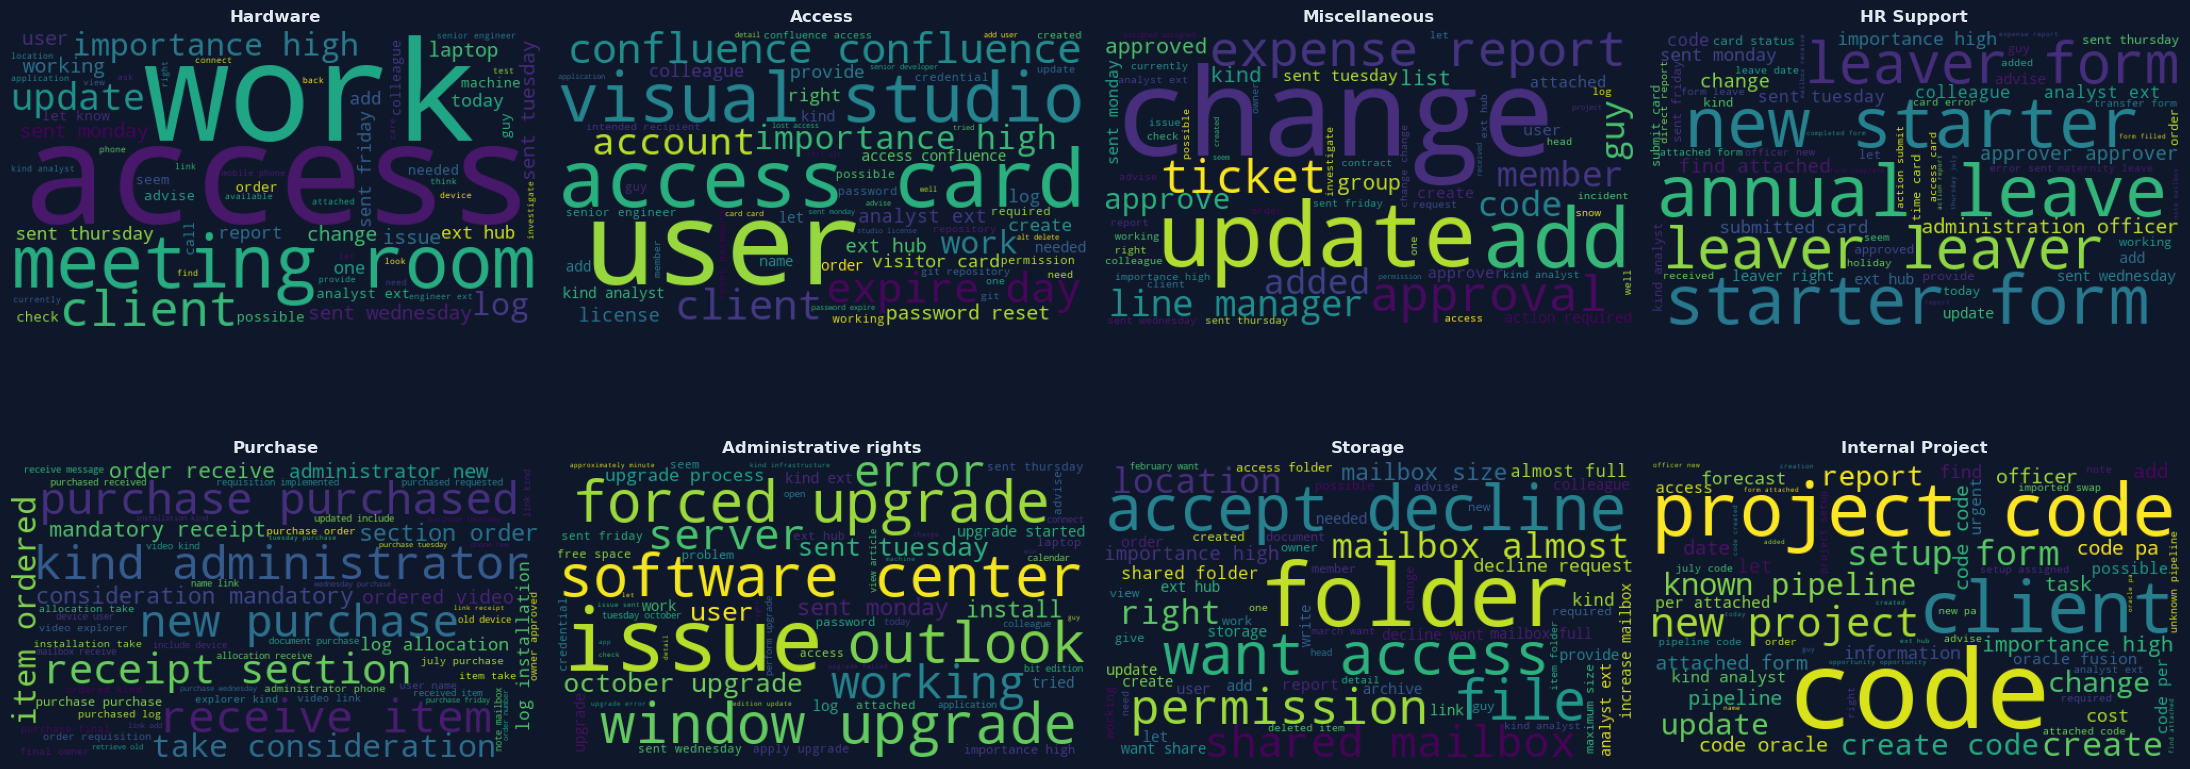

<Figure size 640x480 with 0 Axes>

In [185]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor=BG)

for i, (cat, ax) in enumerate(zip(df_it['Topic_group'].unique(), axes.flatten())):
    corpus = ' '.join(df_it[df_it['Topic_group'] == cat]['clean_text'])

    wc = WordCloud(
        width=500, height=280,
        background_color=CARD,
        max_words=60
    ).generate(corpus)

    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(cat)

plt.tight_layout()
plt.show()
plt.savefig('Wordcloud.png')

In [63]:
# Step 7 — Model Training (IT Ticket Classification)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print('🚀 Training IT Ticket Classification Models...')
print('='*60)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['Topic_group'])

print(f'Classes: {list(le.classes_)}')
print(f'Total samples: {len(y)}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'\nTF-IDF Shape → Train: {X_train_vec.shape}, Test: {X_test_vec.shape}')

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=150),
    'Naive Bayes': MultinomialNB()
}

results = {}

print('\nModel Performance:')
print('-'*60)

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    pre = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1': f1
    }

    print(f'{name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Precision: {pre:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print('-'*60)

# Best model
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']

print(f'🏆 Best Model: {best_model_name} (F1 = {results[best_model_name]["f1"]:.4f})')

🚀 Training IT Ticket Classification Models...
Classes: ['Access', 'Administrative rights', 'HR Support', 'Hardware', 'Internal Project', 'Miscellaneous', 'Purchase', 'Storage']
Total samples: 47821

TF-IDF Shape → Train: (38256, 15000), Test: (9565, 15000)

Model Performance:
------------------------------------------------------------
Logistic Regression
  Accuracy : 0.8506
  F1 Score : 0.8504
  Precision: 0.8552
  Recall   : 0.8506
------------------------------------------------------------
Linear SVM
  Accuracy : 0.8485
  F1 Score : 0.8484
  Precision: 0.8498
  Recall   : 0.8485
------------------------------------------------------------
Random Forest
  Accuracy : 0.8374
  F1 Score : 0.8374
  Precision: 0.8422
  Recall   : 0.8374
------------------------------------------------------------
Naive Bayes
  Accuracy : 0.7720
  F1 Score : 0.7682
  Precision: 0.8031
  Recall   : 0.7720
------------------------------------------------------------
🏆 Best Model: Logistic Regression (F1 = 0

📊 Classification Report (Table Format)



,precision,recall,f1-score,support
Access,0.911,0.879,0.895,1425.000
Administrative rights,0.861,0.597,0.705,352.000
HR Support,0.856,0.863,0.859,2183.000
Hardware,0.785,0.893,0.836,2721.000
Internal Project,0.921,0.795,0.853,424.000
Miscellaneous,0.842,0.807,0.824,1412.000
Purchase,0.975,0.864,0.916,493.000
Storage,0.927,0.823,0.872,555.000
accuracy,0.851,0.851,0.851,0.851
macro avg,0.885,0.815,0.845,9565.000


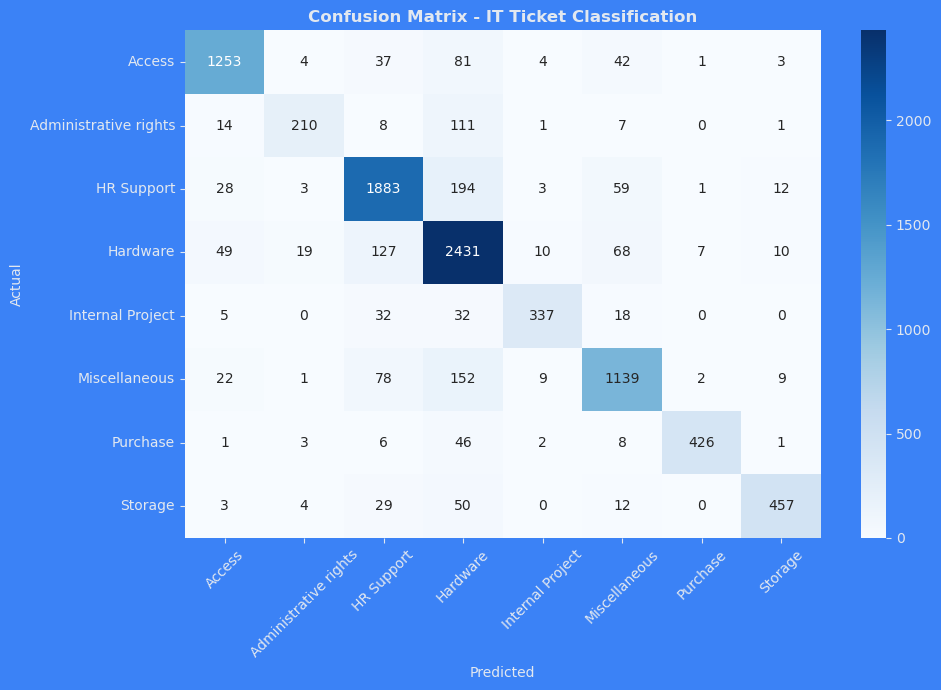

Saved: Confusion_matrix_it.png


In [169]:
# Step 8 — Evaluation
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Round for clean display
report_df = report_df.round(3)

print("📊 Classification Report (Table Format)\n")
display(report_df)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix - IT Ticket Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_it.png')
plt.show()

print('Saved: Confusion_matrix_it.png')

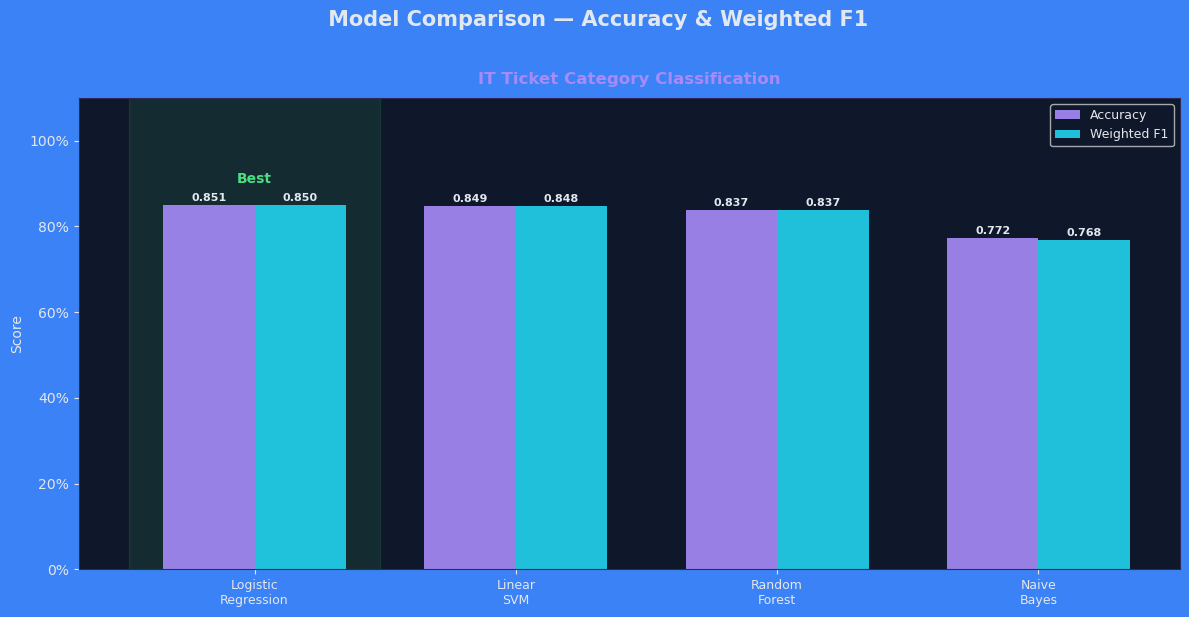

Saved: Model_comparison.png


In [195]:
# Model Comparison Chart (Fixed for your dataset)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)

fig.suptitle(' Model Comparison — Accuracy & Weighted F1',
             fontsize=15, fontweight='bold', color=TXT, y=1.02)

# Use your results dict directly
names = list(results.keys())

# ✅ FIX: correct keys
accs = [results[m]['accuracy'] for m in names]
f1s  = [results[m]['f1'] for m in names]

x, w = np.arange(len(names)), 0.35

# Bars
b1 = ax.bar(x - w/2, accs, w, color=A1, alpha=0.9,
            label='Accuracy', edgecolor='none')
b2 = ax.bar(x + w/2, f1s, w, color=A2, alpha=0.9,
            label='Weighted F1', edgecolor='none')

# Value labels
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TXT)

# Highlight best model
best_idx = int(np.argmax(f1s))
ax.axvspan(best_idx - 0.48, best_idx + 0.48,
           alpha=0.10, color=A3, zorder=0)

ax.text(best_idx, max(f1s) + 0.05, 'Best',
        ha='center', fontsize=10, color=A3, fontweight='bold')

# Formatting
ax.set_title('IT Ticket Category Classification', color=A1, pad=10)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend(fontsize=9)
#ax.grid(axis='y', alpha=0.35)

# Percentage format
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.savefig('Model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

print('Saved: Model_comparison.png')

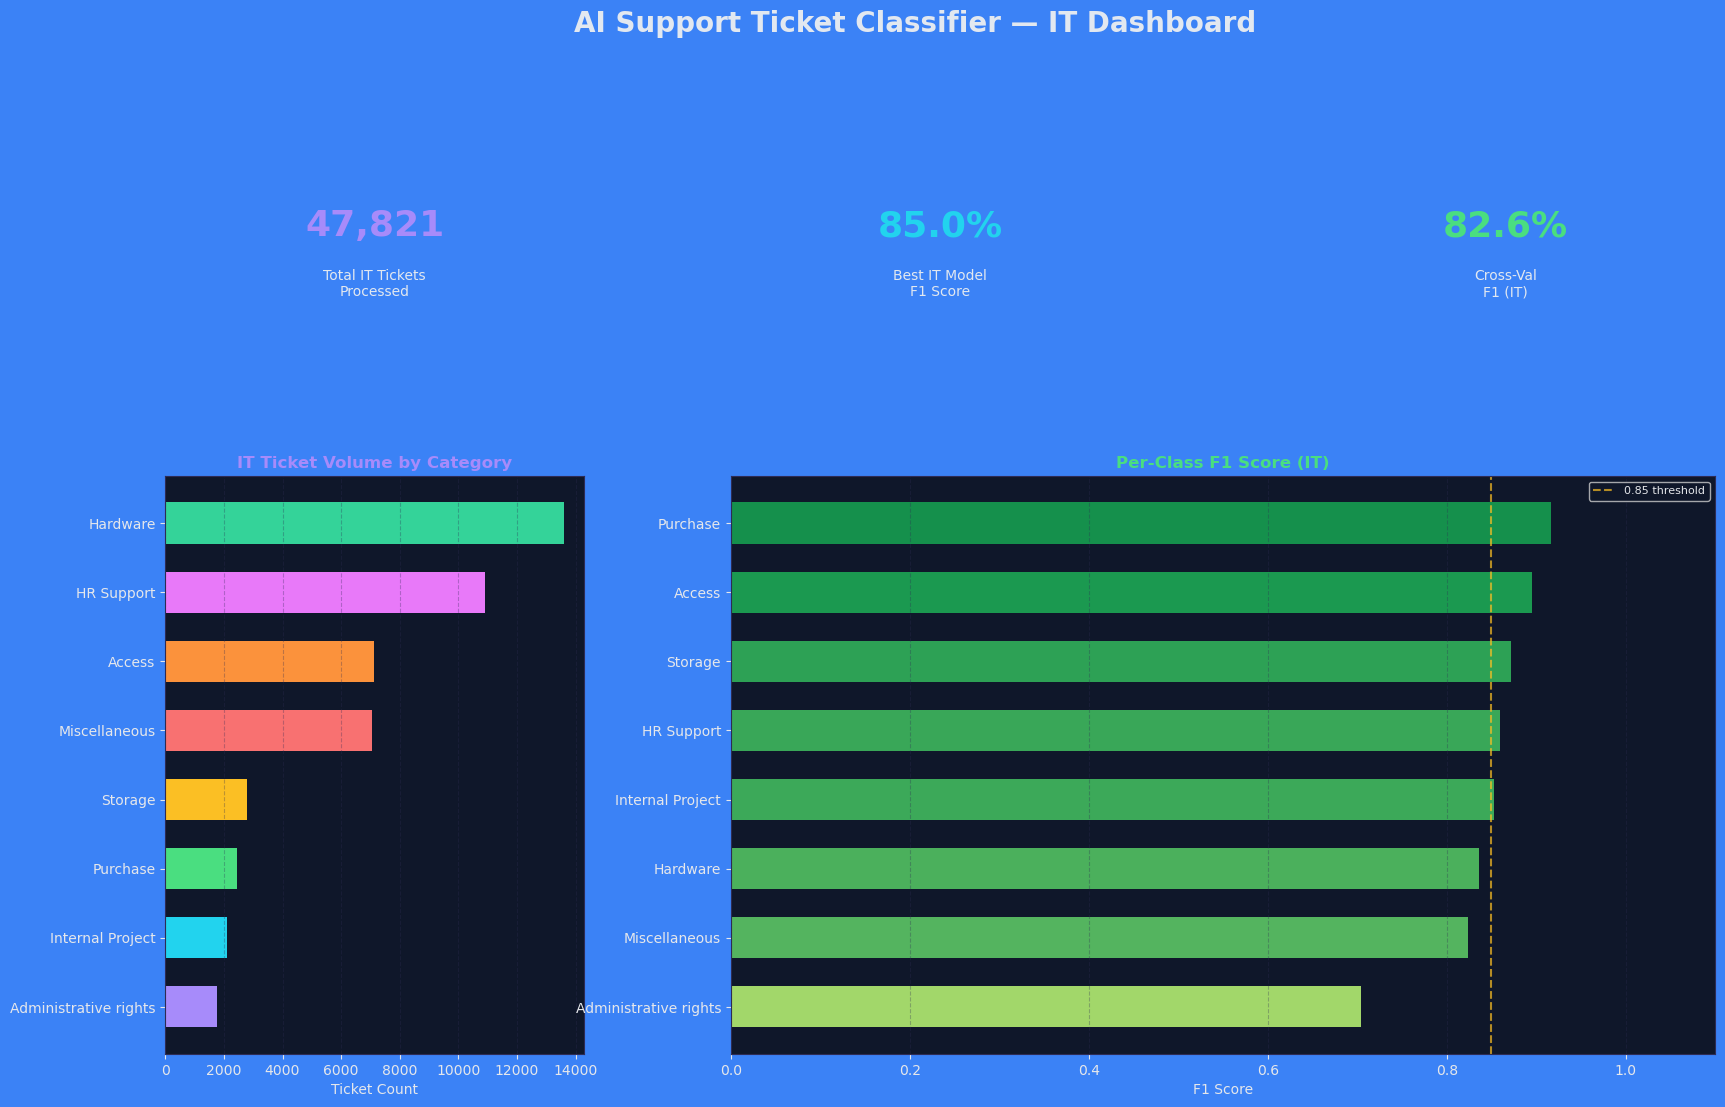

 Saved: It_dashboard.png


In [193]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import classification_report

# Ensure cv_records is a numpy array so mean() works
cv_records = {
    'IT Category': np.array([it_results[name]['f1'] for name in it_results])
}

# Create figure and GridSpec
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('AI Support Ticket Classifier — IT Dashboard',
             fontsize=20, fontweight='bold', color=TXT, y=0.98)

# Grid: 2 rows, 3 columns for KPIs; second row plots
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[0.25, 0.75], hspace=0.4, wspace=0.35)

# KPI Cards
kpi_items = [
    ('Total IT Tickets\nProcessed', f"{len(df_it):,}", A1),
    ('Best IT Model\nF1 Score', f"{it_results[best_it]["f1"]:.1%}", A2),
    ('Cross-Val\nF1 (IT)', f"{cv_records["IT Category"].mean():.1%}", A3)
]

for i, (label, value, color) in enumerate(kpi_items):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    for spine_name, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2.5)
    ax.text(0.5, 0.50, value, ha='center', va='center', fontsize=26, fontweight='bold', color=color)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=10, color=TXT, multialignment='center')

# IT Category Bar Chart
ax_it = fig.add_subplot(gs[1, 0])
it_vc = df_it['Topic_group'].value_counts()
ax_it.barh(it_vc.index[::-1], it_vc.values[::-1],
           color=PALETTE[:len(it_vc)], height=0.6, edgecolor='none')
ax_it.set_title('IT Ticket Volume by Category', color=A1)
ax_it.set_xlabel('Ticket Count')
ax_it.grid(axis='x', alpha=0.3)

# Per-Class F1 Score Bar Chart
ax_hm = fig.add_subplot(gs[1, 1:])
report = classification_report(
    y_it_te, it_results[best_it]['preds'],
    target_names=le_it.classes_, output_dict=True
)
class_f1 = {k: report[k]['f1-score'] for k in le_it.classes_}
classes_sorted = sorted(class_f1, key=class_f1.get, reverse=True)
vals = [class_f1[c] for c in classes_sorted]
cmap_hm = plt.cm.RdYlGn
colors_hm = [cmap_hm(v) for v in vals]
ax_hm.barh(classes_sorted[::-1], vals[::-1], color=colors_hm[::-1], height=0.6, edgecolor='none')
ax_hm.axvline(0.85, color=A4, linestyle='--', alpha=0.7, label='0.85 threshold')
ax_hm.set_xlim(0, 1.1)
ax_hm.set_title('Per-Class F1 Score (IT)', color=A3)
ax_hm.set_xlabel('F1 Score')
ax_hm.legend(fontsize=8)
ax_hm.grid(axis='x', alpha=0.3)

plt.savefig('IT_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Saved: It_dashboard.png')

In [155]:
import os
import pickle
import pandas as pd
import zipfile

# Assign TF-IDF for IT
tfidf_it = tfidf  # from your IT training step

# Create folder
os.makedirs('saved_models', exist_ok=True)

# Only IT artifacts
artifacts_it = {
    'saved_models/tfidf_it.pkl':     tfidf_it,
    'saved_models/model_it_cat.pkl': it_results[best_it]['model'],
    'saved_models/le_it.pkl':        le_it,
}

# Save IT artifacts
for path, obj in artifacts_it.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  💾  {path}')

# IT Metrics summary CSV
rows = []
for name, r in it_results.items():
    preds = r['preds']            # predictions of THIS model
    acc = accuracy_score(y_test, preds)  # compute accuracy for THIS model
    f1  = r['f1']
    rows.append({
        'Task': 'IT Category',
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'Weighted_F1': f"{r['f1']:.4f}"
    })

metrics_df_it = pd.DataFrame(rows)
metrics_df_it.to_csv('model_metrics_it.csv', index=False)
print(f'\n📋 IT Model Metrics:\n{metrics_df_it.to_string(index=False)}')

# Zip IT outputs
output_files_it = ['model_metrics_it.csv', '07_it_dashboard.png'] + list(artifacts_it.keys())

with zipfile.ZipFile('it_ticket_classifier_outputs.zip', 'w') as zf:
    for f in output_files_it:
        if os.path.exists(f):
            zf.write(f)

print('\n📦  IT outputs zipped → it_ticket_classifier_outputs.zip')

  💾  saved_models/tfidf_it.pkl
  💾  saved_models/model_it_cat.pkl
  💾  saved_models/le_it.pkl

📋 IT Model Metrics:
       Task               Model Accuracy Weighted_F1
IT Category Logistic Regression   0.8506      0.8504
IT Category          Linear SVM   0.8485      0.8484
IT Category       Random Forest   0.8374      0.8374
IT Category         Naive Bayes   0.7720      0.7682

📦  IT outputs zipped → it_ticket_classifier_outputs.zip
